# Praktikum Pengolahan Citra
## JOBSHEET 05: MENGUKUR KEMIRIPAN CITRA DAN PENERAPANNYA DALAM PENGENALAN POLA 

**Nama:** Intan Nurul Faizia  
**NIM:** 3.34.23.2.11

**Dosen Pengampu:** Ir. Prayitno, S.ST., M.T., Ph.D.  
**Program Studi:** STR Teknologi Rekayasa Komputer  
**Politeknik Negeri Semarang**

---
## Praktikum 1. Menghitung Jarak Berbasis Piksel (Euclidean & Manhattan)

**Tujuan:** Menghitung dan membandingkan jarak L1 (Manhattan) dan L2 (Euclidean) antara dua patch citra. Jarak lebih kecil berarti patch lebih mirip.

=== Hasil Perhitungan Jarak ===
Jarak Euclidean (L2) Patch1 vs Patch2 : 24.7650
Jarak Euclidean (L2) Patch1 vs Patch3 : 5.0000
Jarak Manhattan (L1) Patch1 vs Patch2 : 936.4392
Jarak Manhattan (L1) Patch1 vs Patch3 : 250.0000


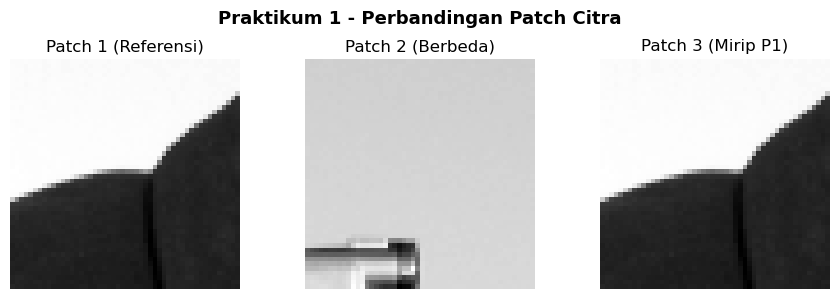

In [1]:
import numpy as np
from skimage import data, img_as_float
from scipy.spatial import distance
import matplotlib.pyplot as plt

# 1. Load citra dan ambil patch
image  = img_as_float(data.camera())
patch1 = image[100:150, 100:150]           # Patch asli
patch2 = image[100:150, 300:350]           # Patch dari lokasi berbeda
patch3 = np.clip(patch1 + 0.1, 0, 1)      # Patch1 + sedikit noise

# 2. Flatten ke vektor 1D
vec1 = patch1.flatten()
vec2 = patch2.flatten()
vec3 = patch3.flatten()

# 3. Hitung Jarak Euclidean (L2)
dist_l2_12 = distance.euclidean(vec1, vec2)
dist_l2_13 = distance.euclidean(vec1, vec3)

# 4. Hitung Jarak Manhattan (L1)
dist_l1_12 = distance.cityblock(vec1, vec2)
dist_l1_13 = distance.cityblock(vec1, vec3)

# 5. Tampilkan hasil
print("=== Hasil Perhitungan Jarak ===")
print(f"Jarak Euclidean (L2) Patch1 vs Patch2 : {dist_l2_12:.4f}")
print(f"Jarak Euclidean (L2) Patch1 vs Patch3 : {dist_l2_13:.4f}")
print(f"Jarak Manhattan (L1) Patch1 vs Patch2 : {dist_l1_12:.4f}")
print(f"Jarak Manhattan (L1) Patch1 vs Patch3 : {dist_l1_13:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(patch1, cmap='gray'); axes[0].set_title('Patch 1 (Referensi)'); axes[0].axis('off')
axes[1].imshow(patch2, cmap='gray'); axes[1].set_title('Patch 2 (Berbeda)');   axes[1].axis('off')
axes[2].imshow(patch3, cmap='gray'); axes[2].set_title('Patch 3 (Mirip P1)'); axes[2].axis('off')

plt.suptitle('Praktikum 1 - Perbandingan Patch Citra', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Praktikum 2. Menghitung Cosine Similarity antara Histogram Warna

**Tujuan:** Mengukur kemiripan antar citra berwarna berdasarkan histogram RGB menggunakan Cosine Similarity. Nilai mendekati 1 = sangat mirip, mendekati 0 = tidak mirip.

=== Cosine Similarity ===
Image1 (Astronaut) vs Image2 (Coffee)          : 0.8156
Image1 (Astronaut) vs Image3 (Astronaut sama)  : 1.0000
Image1 (Astronaut) vs Image4 (Downsampled)     : 1.0000


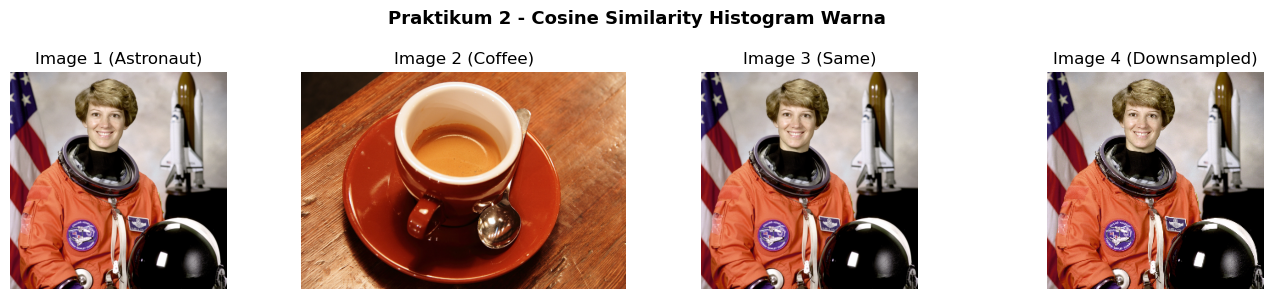

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_ubyte, img_as_float
from scipy.spatial import distance

# Fungsi hitung histogram RGB gabungan
def calculate_rgb_histogram(image, bins=16):
    img_uint8 = img_as_ubyte(image)
    hist_r, _ = np.histogram(img_uint8[:,:,0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(img_uint8[:,:,1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(img_uint8[:,:,2].ravel(), bins=bins, range=(0, 256))
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))
    hist_combined = hist_combined.astype(float) / np.sum(hist_combined)  # Normalisasi
    return hist_combined

# 1. Muat citra
image1 = data.astronaut()          # Citra astronaut
image2 = data.coffee()             # Citra berbeda
image3 = data.astronaut()          # Citra sama dengan image1
image4 = image1[::2, ::2, :]      # Versi downsampled image1

# 2. Hitung histogram
hist1 = calculate_rgb_histogram(image1)
hist2 = calculate_rgb_histogram(image2)
hist3 = calculate_rgb_histogram(image3)
hist4 = calculate_rgb_histogram(image4)

# 3. Hitung Cosine Similarity
sim_12 = 1 - distance.cosine(hist1, hist2)
sim_13 = 1 - distance.cosine(hist1, hist3)
sim_14 = 1 - distance.cosine(hist1, hist4)

print("=== Cosine Similarity ===")
print(f"Image1 (Astronaut) vs Image2 (Coffee)          : {sim_12:.4f}")
print(f"Image1 (Astronaut) vs Image3 (Astronaut sama)  : {sim_13:.4f}")
print(f"Image1 (Astronaut) vs Image4 (Downsampled)     : {sim_14:.4f}")

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
axes[0].imshow(image1); axes[0].set_title('Image 1 (Astronaut)'); axes[0].axis('off')
axes[1].imshow(image2); axes[1].set_title('Image 2 (Coffee)');    axes[1].axis('off')
axes[2].imshow(image3); axes[2].set_title('Image 3 (Same)');      axes[2].axis('off')
axes[3].imshow(image4); axes[3].set_title('Image 4 (Downsampled)'); axes[3].axis('off')

plt.suptitle('Praktikum 2 - Cosine Similarity Histogram Warna', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Praktikum 3. Menghitung Structural Similarity Index (SSIM)

**Tujuan:** Mengukur kemiripan struktural antara citra menggunakan SSIM yang meniru persepsi visual manusia. SSIM = 1 berarti identik, semakin mendekati 0 semakin tidak mirip.

=== Nilai SSIM ===
SSIM (Ref vs Same)     : 1.0000
SSIM (Ref vs Noisy)    : 0.2952
SSIM (Ref vs Contrast) : 0.9651
SSIM (Ref vs Blurred)  : 0.8027


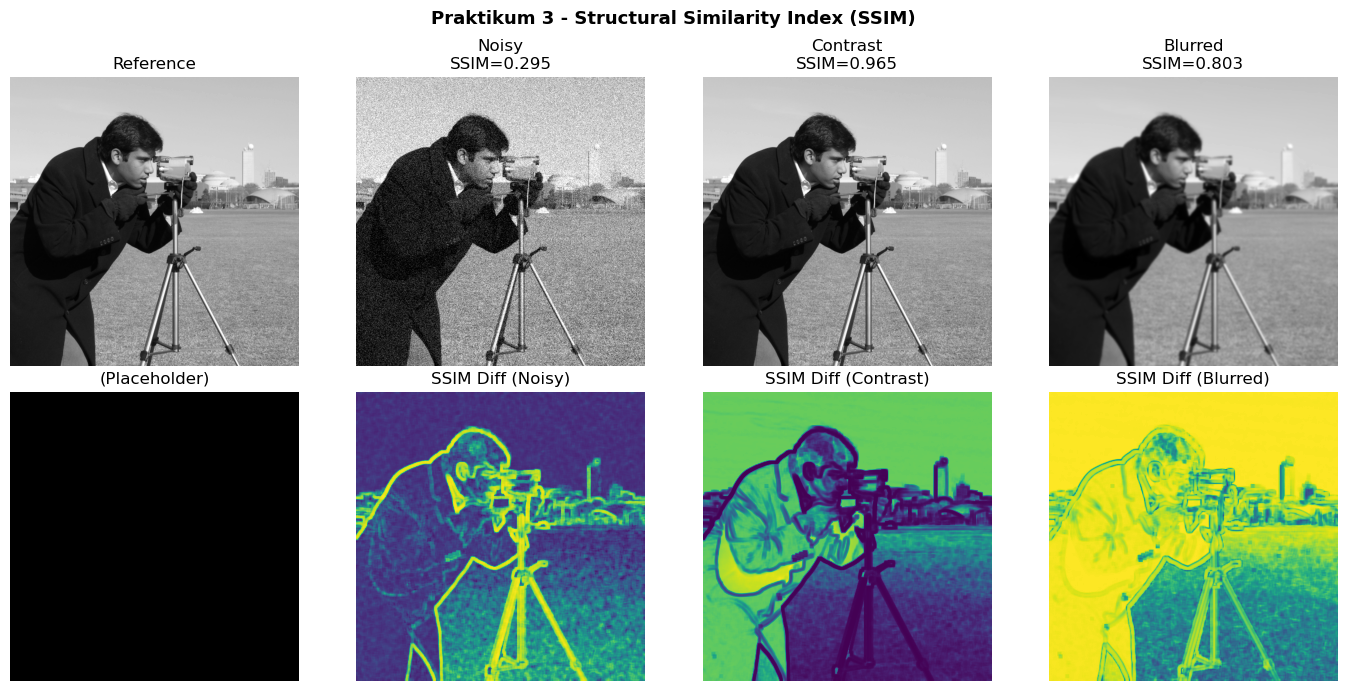

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.metrics import structural_similarity as ssim
from skimage.util import random_noise
from skimage.filters import gaussian

# 1. Load citra referensi
image_ref = img_as_float(data.camera())

# 2. Buat versi terdistorsi
image_same     = image_ref.copy()                                    # Identik
image_noisy    = random_noise(image_ref, mode='gaussian', var=0.01)  # + Noise
image_contrast = np.clip(image_ref * 0.8, 0, 1)                     # Kontras dikurangi
image_blurred  = gaussian(image_ref, sigma=1.5, channel_axis=None)  # Di-blur

# 3. Hitung SSIM
data_range = image_ref.max() - image_ref.min()
ssim_same,     _            = ssim(image_ref, image_same,     data_range=data_range, full=True)
ssim_noisy,    diff_noisy   = ssim(image_ref, image_noisy,    data_range=data_range, full=True)
ssim_contrast, diff_contrast= ssim(image_ref, image_contrast, data_range=data_range, full=True)
ssim_blurred,  diff_blurred = ssim(image_ref, image_blurred,  data_range=data_range, full=True)

print("=== Nilai SSIM ===")
print(f"SSIM (Ref vs Same)     : {ssim_same:.4f}")
print(f"SSIM (Ref vs Noisy)    : {ssim_noisy:.4f}")
print(f"SSIM (Ref vs Contrast) : {ssim_contrast:.4f}")
print(f"SSIM (Ref vs Blurred)  : {ssim_blurred:.4f}")

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
ax = axes.ravel()

ax[0].imshow(image_ref,      cmap='gray'); ax[0].set_title('Reference');                          ax[0].axis('off')
ax[1].imshow(image_noisy,    cmap='gray'); ax[1].set_title(f'Noisy\nSSIM={ssim_noisy:.3f}');     ax[1].axis('off')
ax[2].imshow(image_contrast, cmap='gray'); ax[2].set_title(f'Contrast\nSSIM={ssim_contrast:.3f}');ax[2].axis('off')
ax[3].imshow(image_blurred,  cmap='gray'); ax[3].set_title(f'Blurred\nSSIM={ssim_blurred:.3f}'); ax[3].axis('off')

ax[4].imshow(np.zeros_like(image_ref), cmap='gray'); ax[4].set_title('(Placeholder)'); ax[4].axis('off')
ax[5].imshow(diff_noisy,    cmap='viridis'); ax[5].set_title('SSIM Diff (Noisy)');    ax[5].axis('off')
ax[6].imshow(diff_contrast, cmap='viridis'); ax[6].set_title('SSIM Diff (Contrast)'); ax[6].axis('off')
ax[7].imshow(diff_blurred,  cmap='viridis'); ax[7].set_title('SSIM Diff (Blurred)');  ax[7].axis('off')

plt.suptitle('Praktikum 3 - Structural Similarity Index (SSIM)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Praktikum 4. Penerapan Template Matching

**Tujuan:** Menemukan lokasi sebuah template (potongan gambar kecil) di dalam citra yang lebih besar menggunakan Normalized Cross-Correlation. Lokasi dengan nilai tertinggi = lokasi template ditemukan.

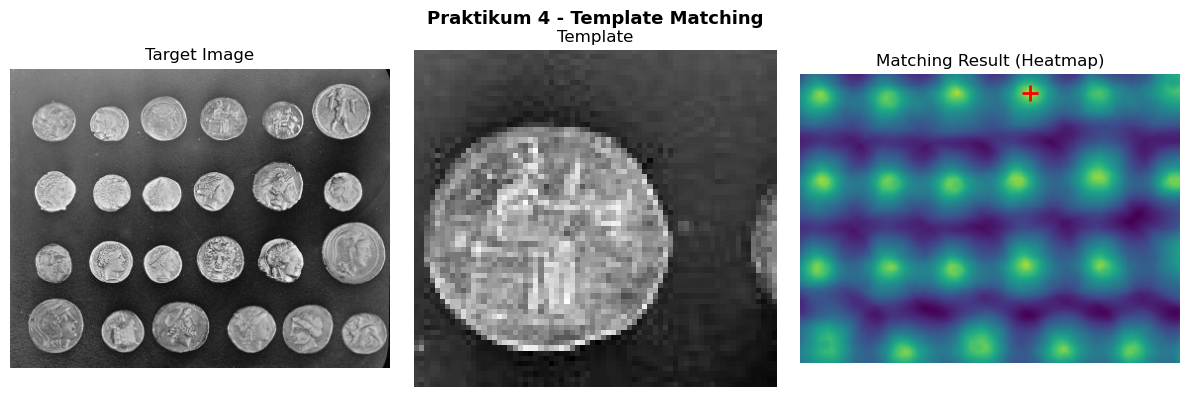

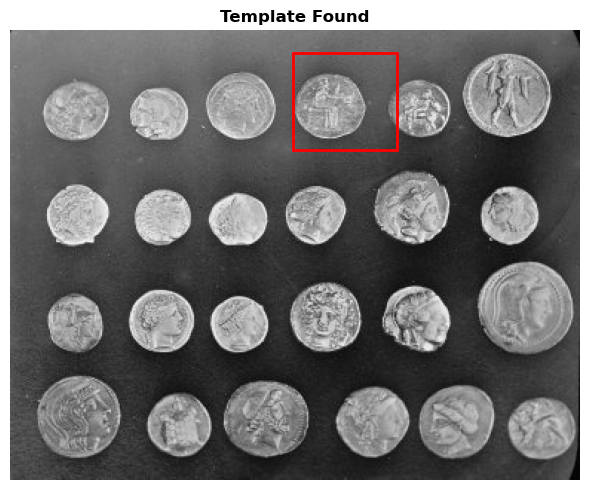

Template ditemukan di koordinat (x,y): (190, 15)
Skor matching tertinggi             : 1.0000


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template

# 1. Load citra target dan ambil template (salah satu koin)
image    = data.coins()
template = image[15:80, 190:260]

# 2. Template matching menggunakan Normalized Cross-Correlation
result = match_template(image, template)

# 3. Temukan lokasi skor tertinggi
ij   = np.unravel_index(np.argmax(result), result.shape)
x, y = ij[::-1]

# 4. Visualisasi heatmap
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].imshow(image, cmap='gray')
ax[0].set_title('Target Image'); ax[0].axis('off')

ax[1].imshow(template, cmap='gray')
ax[1].set_title('Template'); ax[1].axis('off')

ax[2].imshow(result, cmap='viridis')
ax[2].set_title('Matching Result (Heatmap)')
ax[2].plot(x, y, 'r+', markersize=12, markeredgewidth=2)
ax[2].axis('off')

plt.suptitle('Praktikum 4 - Template Matching', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 5. Tampilkan hasil kotak pada citra asli
fig2, ax_main = plt.subplots(figsize=(6, 6))
ax_main.imshow(image, cmap='gray')
ax_main.set_title('Template Found', fontweight='bold')
ax_main.axis('off')
h, w = template.shape
rect = plt.Rectangle((x, y), w, h, edgecolor='r', facecolor='none', lw=2)
ax_main.add_patch(rect)
plt.tight_layout()
plt.show()

print(f"Template ditemukan di koordinat (x,y): ({x}, {y})")
print(f"Skor matching tertinggi             : {result.max():.4f}")

---
## Praktikum 5. Simulasi Content-Based Image Retrieval (CBIR) Sederhana

**Tujuan:** Mensimulasikan sistem pencarian citra berdasarkan kemiripan histogram warna. Citra dengan jarak histogram terkecil terhadap query dianggap paling mirip.

Memproses database citra...
  - astronaut diproses.
  - camera diproses.
  - coffee diproses.
  - coins diproses.
  - chelsea diproses.

=== Hasil Retrieval ===
Rank 1: chelsea (Distance: 0.0000)
Rank 2: coins (Distance: 0.2879)
Rank 3: coffee (Distance: 0.3593)
Rank 4: astronaut (Distance: 0.4612)
Rank 5: camera (Distance: 0.6020)


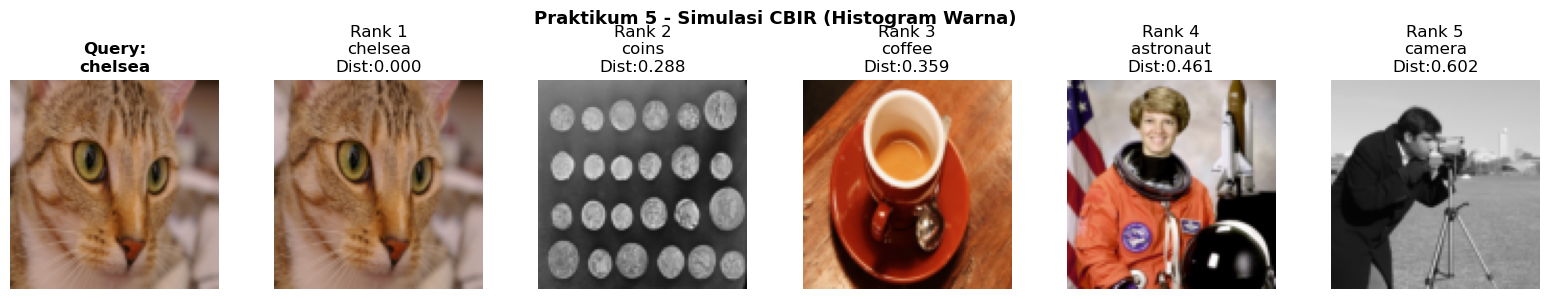

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform, img_as_float, img_as_ubyte
from scipy.spatial import distance

# Fungsi hitung histogram RGB
def calculate_rgb_histogram(image, bins=16):
    if image.dtype != np.uint8:
        image = img_as_ubyte(image)
    hist_r, _ = np.histogram(image[:,:,0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(image[:,:,1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(image[:,:,2].ravel(), bins=bins, range=(0, 256))
    hist_combined = np.concatenate((hist_r, hist_g, hist_b)).astype(float)
    hist_sum = np.sum(hist_combined)
    if hist_sum > 0:
        hist_combined /= hist_sum
    return hist_combined

# 1. Siapkan database citra
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_hists  = []

print("Memproses database citra...")
for name in image_db_names:
    img = getattr(data, name)()
    if img.ndim == 2:                        # Grayscale -> RGB
        img = color.gray2rgb(img)
    img_resized = transform.resize(img, (100, 100), anti_aliasing=True)
    img_uint8   = img_as_ubyte(img_resized)
    database_images.append(img_uint8)
    database_hists.append(calculate_rgb_histogram(img_uint8))
    print(f"  - {name} diproses.")

# 2. Pilih query (chelsea)
query_image_name = "chelsea"
query_index      = image_db_names.index(query_image_name)
query_image      = database_images[query_index]
query_hist       = database_hists[query_index]

# 3. Hitung Cosine Distance ke semua citra
distances = [distance.cosine(query_hist, h) for h in database_hists]

# 4. Urutkan berdasarkan jarak terkecil
sorted_indices = np.argsort(distances)

# 5. Visualisasi
fig, axes = plt.subplots(1, len(database_images) + 1, figsize=(16, 3))

axes[0].imshow(query_image)
axes[0].set_title(f'Query:\n{query_image_name}', fontweight='bold')
axes[0].axis('off')

print("\n=== Hasil Retrieval ===")
for rank, idx in enumerate(sorted_indices):
    axes[rank + 1].imshow(database_images[idx])
    axes[rank + 1].set_title(f'Rank {rank+1}\n{image_db_names[idx]}\nDist:{distances[idx]:.3f}')
    axes[rank + 1].axis('off')
    print(f"Rank {rank+1}: {image_db_names[idx]} (Distance: {distances[idx]:.4f})")

plt.suptitle('Praktikum 5 - Simulasi CBIR (Histogram Warna)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()